### Model Evaluation
Our model for predicting regional sea level rise will be tested against the values for sea level rise from NASA which are obtained from the IPCC AR6 report.

The evaluation metrics will be Mean Bias Error (MBE) and RMSE (Root-Mean Squared Error)

In [22]:
# Imports
import xarray as xr
import numpy as np

In [23]:
# Load SLR data
# SSP1-2.6
ssp126_ds = xr.open_dataset("./regional_rise/slr_ssp126.nc")
ssp126_slr = (ssp126_ds["slr"].sel(time=2100) - ssp126_ds["slr"].sel(time=2015)) / 10
# SSP2-4.5
ssp245_ds = xr.open_dataset("./regional_rise/slr_ssp245.nc")
ssp245_slr = (ssp245_ds["slr"].sel(time=2100) - ssp245_ds["slr"].sel(time=2015)) / 10
# SSP3-7.0
ssp370_ds = xr.open_dataset("./regional_rise/slr_ssp370.nc")
ssp370_slr = (ssp370_ds["slr"].sel(time=2100) - ssp370_ds["slr"].sel(time=2015)) / 10
# SSP5-8.5
ssp585_ds = xr.open_dataset("./regional_rise/slr_ssp585.nc")
ssp585_slr = (ssp585_ds["slr"].sel(time=2100) - ssp585_ds["slr"].sel(time=2015)) / 10

In [29]:
import numpy as np

decades = [2030, 2040, 2050, 2060, 2070, 2080, 2090, 2100]

ssp126_brick_projections = []
ssp245_brick_projections = []
ssp370_brick_projections = []
ssp585_brick_projections = []

def get_global_mean_projection(ds, baseline_year=2020):
    projections = []
    
    weights = np.cos(np.deg2rad(ds["lat"]))
    weights = weights / weights.mean()
    
    baseline = ds["slr"].sel(time=baseline_year)
    
    for year in decades:
        slr_diff = ds["slr"].sel(time=year) - baseline
        global_mean = slr_diff.weighted(weights).mean(("lat", "lon"))
        projections.append(float(global_mean.values))
    
    return projections

ssp126_brick_projections = get_global_mean_projection(ssp126_ds)
ssp245_brick_projections = get_global_mean_projection(ssp245_ds)
ssp370_brick_projections = get_global_mean_projection(ssp370_ds)
ssp585_brick_projections = get_global_mean_projection(ssp585_ds)

ssp126_brick_projections = [v*10 for v in ssp126_brick_projections]
ssp245_brick_projections = [v*10 for v in ssp245_brick_projections]
ssp370_brick_projections = [v*10 for v in ssp370_brick_projections]
ssp585_brick_projections = [v*10 for v in ssp585_brick_projections]

print("SSP1-2.6:", ssp126_brick_projections)
print("SSP2-4.5:", ssp245_brick_projections)
print("SSP3-7.0:", ssp370_brick_projections)
print("SSP5-8.5:", ssp585_brick_projections)

SSP1-2.6: [5.634729868664169, 11.404483415371097, 17.111731124855954, 22.83871564261192, 28.555131270105836, 34.222779539869265, 39.71398879469464, 45.172041746804965]
SSP2-4.5: [5.534916487263346, 11.338945875527351, 17.264606516414794, 23.257732727063882, 29.41253016961089, 35.625148430429476, 41.9718727269732, 48.34091008997153]
SSP3-7.0: [5.541219798350213, 11.271477295312538, 17.182743345956272, 23.338274813897502, 29.70661020870272, 36.31782693274762, 43.515540159789126, 50.83576102244556]
SSP5-8.5: [5.720959247449038, 11.6390900754293, 17.854722674339556, 24.281158300474296, 31.226565385484083, 38.62898578103308, 46.682766092750384, 55.247923020233515]


NASA Data (obtained from: https://sealevel.nasa.gov/ipcc-ar6-sea-level-projection-tool?type=global)

In [30]:
ssp126_nasa_projections = [9, 14, 19, 23, 29, 34, 39, 44]
ssp245_nasa_projections = [9, 14, 20, 26, 33, 40, 48, 56]
ssp370_nasa_projections = [9, 14, 21, 28, 37, 46, 56, 68]
ssp585_nasa_projections = [10, 16, 23, 31, 40, 51, 63, 77]

Since our predictions are constantly lower than those NASA provides, the best evaluation metric to use is Mean Bias Error (MBE) since it provides both direction and magnitude. We have also included RMSE (root-mean squared error) for an overall estimate of error size

In [32]:
import numpy as np
import pandas as pd

def evaluate(brick, nasa):
    brick = np.array(brick)
    nasa = np.array(nasa)

    bias = np.mean(brick - nasa)
    rmse = np.sqrt(np.mean((brick - nasa)**2))

    return bias, rmse

results = {}

results["SSP1-2.6"] = evaluate(ssp126_brick_projections, ssp126_nasa_projections)
results["SSP2-4.5"] = evaluate(ssp245_brick_projections, ssp245_nasa_projections)
results["SSP3-7.0"] = evaluate(ssp370_brick_projections, ssp370_nasa_projections)
results["SSP5-8.5"] = evaluate(ssp585_brick_projections, ssp585_nasa_projections)

df = pd.DataFrame(results, index=["Bias (cm)", "RMSE (cm)"]).T

print(df.round(3))

          Bias (cm)  RMSE (cm)
SSP1-2.6     -0.793      1.724
SSP2-4.5     -4.157      4.487
SSP3-7.0     -7.661      9.035
SSP5-8.5     -9.965     11.610


Interpretation: All the values for MBE are constantly negative, meaning that on a decade-to-decade basis, the values for sea level rise are underestimated in our model (BRICK) compared to NASA's model (used in IPCC AR6). Additionally, the RMSE increases as emissions increase, indicating that our model is less sensitive to higher emissions than NASA's and that underestimations increase as emissions increase.

Plots

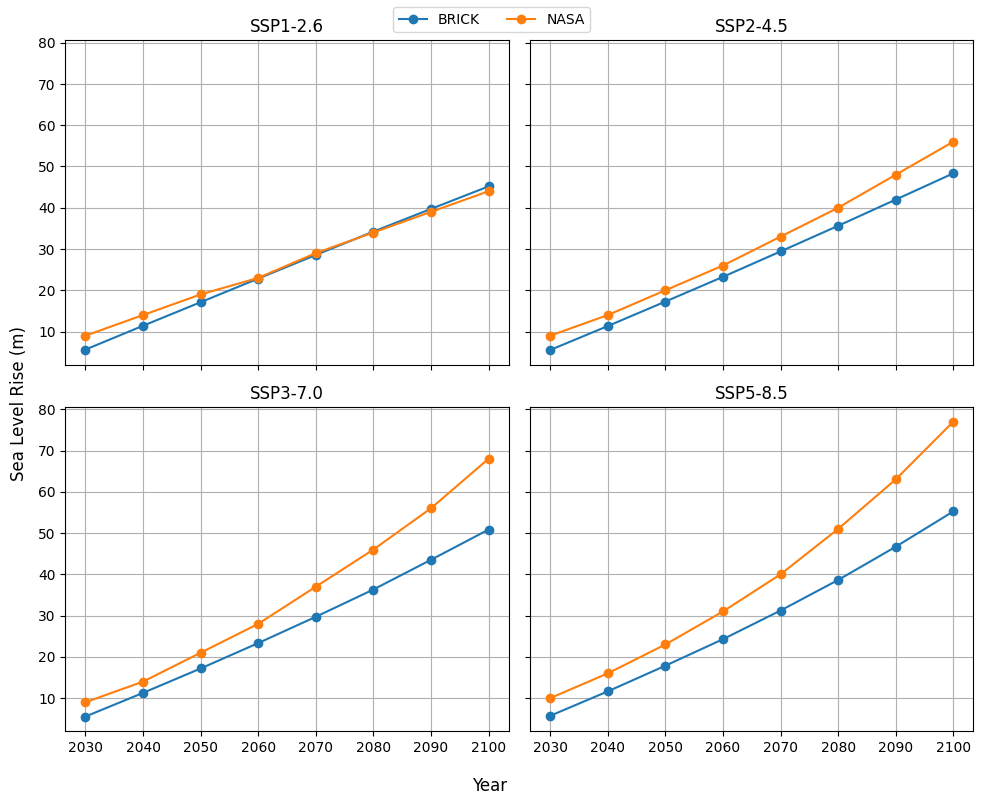

In [41]:
import matplotlib.pyplot as plt

years = [2030,2040,2050,2060,2070,2080,2090,2100]

fig, axes = plt.subplots(2,2, figsize=(10,8), sharex=True, sharey=True)

scenarios = [
    ("SSP1-2.6", ssp126_brick_projections, ssp126_nasa_projections),
    ("SSP2-4.5", ssp245_brick_projections, ssp245_nasa_projections),
    ("SSP3-7.0", ssp370_brick_projections, ssp370_nasa_projections),
    ("SSP5-8.5", ssp585_brick_projections, ssp585_nasa_projections)
]

handles = None

for ax, (name, brick, nasa) in zip(axes.flatten(), scenarios):
    line1, = ax.plot(years, brick, marker='o', label="BRICK")
    line2, = ax.plot(years, nasa, marker='o', label="NASA")
    
    if handles is None:
        handles = [line1, line2]

    ax.set_title(name)
    ax.grid(True)

fig.supxlabel("Year")
fig.supylabel("Sea Level Rise (m)")

fig.legend(handles, ["BRICK", "NASA"], loc="upper center", ncol=2)

plt.tight_layout()
plt.show()

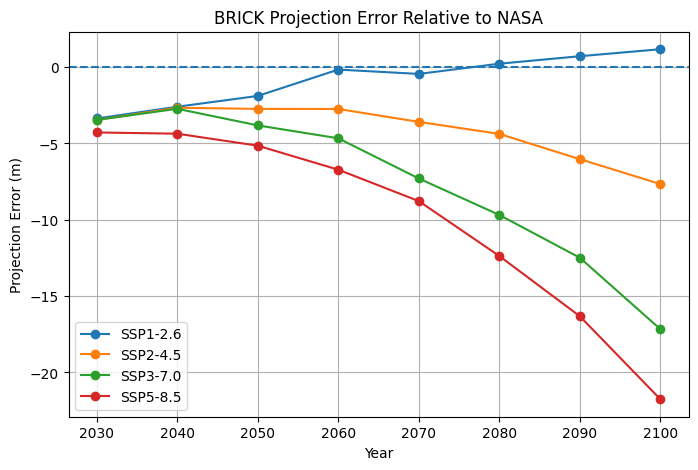

In [42]:
import numpy as np

plt.figure(figsize=(8,5))

plt.plot(years, np.array(ssp126_brick_projections) - np.array(ssp126_nasa_projections), marker='o', label="SSP1-2.6")
plt.plot(years, np.array(ssp245_brick_projections) - np.array(ssp245_nasa_projections), marker='o', label="SSP2-4.5")
plt.plot(years, np.array(ssp370_brick_projections) - np.array(ssp370_nasa_projections), marker='o', label="SSP3-7.0")
plt.plot(years, np.array(ssp585_brick_projections) - np.array(ssp585_nasa_projections), marker='o', label="SSP5-8.5")

plt.axhline(0, linestyle="--")

plt.xlabel("Year")
plt.ylabel("Projection Error (m)")
plt.title("BRICK Projection Error Relative to NASA")
plt.legend()
plt.grid(True)

plt.show()

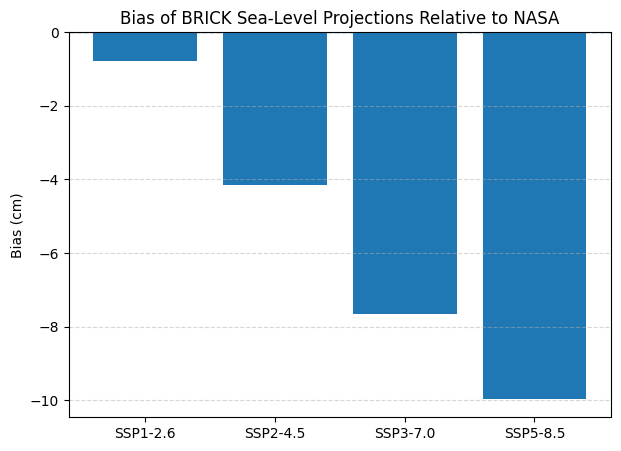

In [43]:
import matplotlib.pyplot as plt
import numpy as np

scenarios = ["SSP1-2.6", "SSP2-4.5", "SSP3-7.0", "SSP5-8.5"]
bias = [-0.793, -4.157, -7.661, -9.965]  # in cm

plt.figure(figsize=(7,5))

bars = plt.bar(scenarios, bias)

plt.axhline(0, linestyle="--", linewidth=1)
plt.ylabel("Bias (cm)")
plt.title("Bias of BRICK Sea-Level Projections Relative to NASA")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()